In [ ]:
# import all packages
import numpy as np
import pandas as pd
import glob, os
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import math
import statsmodels.formula.api as sm
from statsmodels.stats.anova import anova_lm
import geopandas as gpd
# from plot_functions import plot_50states

### Read roadway lengths

In [ ]:
# folder_path = r'D:\Work\Box Sync\Quantify Infrastructure\Streets_df\All states'
folder_path = r'E:\Scripts\data\osm\All states'

# Get a list of all CSV files in the folder
csv_files = [file for file in os.listdir(folder_path) if file.endswith('.csv')]

# Initialize an empty DataFrame to store concatenated data
concatenated_df = pd.DataFrame()

# Loop through each CSV file and concatenate them
for file in csv_files:
    # print(file)
    file_path = os.path.join(folder_path, file)
    
    # Read the CSV file into a DataFrame
    df_state = pd.read_csv(file_path, index_col =0)
    # to check how many places are excluded
    # print(df_state.shape[0])
    # count = count + df_state.shape[0]
    df_state['GEOID'] = df_state['GEOID'].astype(str).str.rjust(7, '0')
    
    # Concatenate the DataFrame to the existing data
    concatenated_df = pd.concat([concatenated_df, df_state], ignore_index=True)
print(concatenated_df.shape)

# 13 missing places due to missing geometry
# Total no of places for 50 states in 2020
# 31249+13 = 31262

(31257, 74)


In [ ]:
os.environ['USE_PYGEOS'] = '0'
# Import places map
places_US = gpd.read_file(r'E:\Scripts\data\tigerline_shapefiles\all_places\compiled.shp')
print(places_US.shape)

places_50_states = places_US[(places_US['STATEFP'] != '02') & (places_US['STATEFP'] != '60') & (places_US['STATEFP'] != '66') & (places_US['STATEFP'] != '69') & (places_US['STATEFP'] != '72') & (places_US['STATEFP'] != '78')]

print(places_50_states.shape)

(32188, 17)
(31262, 17)


<Axes: >

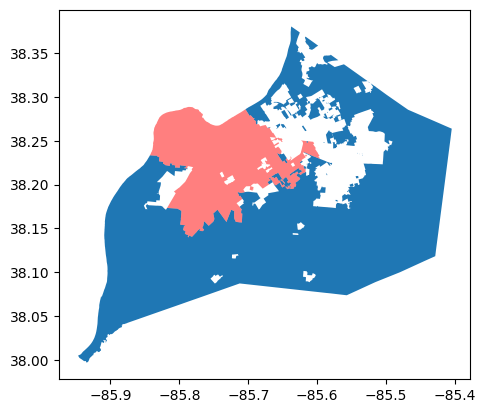

In [ ]:
ax = places_50_states[places_50_states['GEOID'] == '2148006'].plot() # 	Louisville/Jefferson County metro government 
places_50_states[places_50_states['GEOID'] == '2148000'].plot(ax=ax, color='red', alpha = 0.5) # 	Louisville city

In [ ]:
concatenated_df[['GEOID', 'NAMELSAD',  'secondary', 'tertiary', 'unclassified', 'residential', 'cl_tertiary', 'cl_unclassified', 'cl_residential', 'cl_service', 
                'lane_m_tertiary', 'lane_m_unclassified', 'lane_m_residential', 'lane_m_service', 'lane_m_living_street']]

,GEOID,NAMELSAD,secondary,tertiary,unclassified,residential,cl_tertiary,cl_unclassified,cl_residential,cl_service,lane_m_tertiary,lane_m_unclassified,lane_m_residential,lane_m_service,lane_m_living_street
0,0102260,Ardmore town,4515.602482,3414.774786,4679.351779,37801.086488,1707.387393,2339.675890,18935.832311,0.0,3414.774786,4679.351779,37801.086488,0.0,0.0
1,0151264,Mooresville town,0.000000,1221.009218,0.000000,4847.498766,665.526838,0.000000,2454.805855,0.0,1221.009218,0.000000,4847.498766,0.0,0.0
2,0171496,Somerville town,16702.050370,0.000000,0.000000,42007.387675,0.000000,0.000000,21003.693838,0.0,0.000000,0.000000,42007.387675,0.0,0.0
3,0176872,Trinity town,0.000000,24753.439644,3779.474886,64473.206717,12376.719822,1889.737443,32412.521614,0.0,24753.439644,3779.474886,65119.263280,0.0,0.0
4,0130880,Goshen town,0.000000,12662.955318,2292.404495,16229.565230,6331.477659,1146.202247,8114.782615,0.0,12662.955318,2292.404495,16229.565230,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31252,5682967,Westview Circle CDP,0.000000,4263.347727,10043.795432,0.000000,2131.673863,5021.897716,0.000000,0.0,4263.347727,10043.795432,0.000000,0.0,0.0
31253,5683100,Whiting CDP,905.820922,0.000000,3700.969039,10038.096588,0.000000,1850.484519,5019.048294,0.0,0.000000,3700.969039,10038.096588,0.0,0.0
31254,5683765,Wilson CDP,0.000000,16248.866529,12445.031137,101746.758794,8124.433264,6222.515569,50873.379397,0.0,16248.866529,12445.031137,101746.758794,0.0,0.0
31255,5684852,Woods Landing-Jelm CDP,11219.746664,0.402589,77.105373,37021.023978,0.201295,38.552687,18510.511989,0.0,0.402589,77.105373,37021.023978,0.0,0.0


In [ ]:
df = concatenated_df.copy()

In [ ]:
# Calculate total roadway length and total centerline roadway length
roadway_columns = ['motorway', 'trunk', 'primary', 'secondary', 'tertiary', 'unclassified', 'residential', 'service', 'living_street']
cl_roadway_columns = ['cl_motorway', 'cl_trunk', 'cl_primary', 'cl_secondary', 'cl_tertiary', 'cl_unclassified', 'cl_residential']
lane_m_roadway_columns = ['lane_m_motorway', 'lane_m_trunk', 'lane_m_primary','lane_m_secondary', 'lane_m_tertiary', 'lane_m_unclassified',
                          'lane_m_residential', 'lane_m_service', 'lane_m_track','lane_m_footway', 'lane_m_cycleway', 'lane_m_living_street']
cl_local_columns = ['cl_unclassified', 'cl_residential', 'cl_service'] # 'cl_secondary'
lane_m_local_columns =['lane_m_unclassified', 'lane_m_residential', 'lane_m_service','lane_m_living_street'] # 'lane_m_secondary', 'lane_m_track','lane_m_footway', 'lane_m_cycleway',
footway_columns = ['footway','n_residential','n_footway']

df['total_length'] = df[roadway_columns].sum(axis=1)
df['cl_all_classes'] = df[cl_roadway_columns].sum(axis=1)
df['lane_m_all_classes'] = df[lane_m_roadway_columns].sum(axis=1)
df['cl_local_length'] = df[cl_local_columns].sum(axis=1)
df['cl_total_length'] = df[lane_m_local_columns].sum(axis=1) 
df['walkway_length'] = df[footway_columns].sum(axis=1)

# df['road_area_m2'] = df['motorway'] * 13.6 + df['trunk'] * 9.6 + df['primary'] * 6.0 + df['secondary'] * 5.3 + df['tertiary'] * 4.9 +\
#       df['unclassified'] * 4.5 + df['residential'] * 4.5
df['road_lanearea_m2'] = df['lane_m_all_classes'] * 3.6

df['pct_cl_local'] = df['cl_local_length'] * 100 / df['cl_all_classes']
df['pct_local'] = df['cl_total_length'] * 100 / df['lane_m_all_classes']
df['pct_walkway'] = df['walkway_length']*100/df['cl_total_length'] # This value need to be checked since residential (auto) can have walkways too

In [ ]:
print(f"Total cities with zero local roadways:==== {df[(df['cl_total_length']==0)].shape[0]}")
print(f"CDPs with zero local roadways:==== {df[(df['NAMELSAD'].str.contains('CDP')) & (df['cl_total_length']==0)].shape[0]}")
print(f"CDPs with local roadways:==== {df[(df['NAMELSAD'].str.contains('CDP')) & (df['cl_total_length']!=0)].shape[0]}")
print(f"Total non-zero local lane-meter available for {df[(df['cl_total_length']!=0)].shape[0]} cities")
# df[(df['NAMELSAD'].str.contains('CDP')) &(df['cl_total_length']!=0)]

Total cities with zero local roadways:==== 61
CDPs with zero local roadways:==== 50
CDPs with local roadways:==== 11837
Total non-zero local lane-meter available for 31196 cities


In [ ]:
df[(df['NAMELSAD'].str.contains('CDP')) &(df['cl_total_length']!=0)][['GEOID', 'NAMELSAD', 'total_length', 'cl_all_classes', 'lane_m_all_classes', 'cl_total_length','pct_local']].sort_values(by=['pct_local']).round(2)

,GEOID,NAMELSAD,total_length,cl_all_classes,lane_m_all_classes,cl_total_length,pct_local
11744,2481925,Waterview CDP,3525.54,1762.77,3525.54,2.54,0.07
22564,4105700,Bellfountain CDP,8238.62,4119.31,8238.62,7.22,0.09
5722,1510900,Haliimaile CDP,12810.60,6405.30,12810.60,11.51,0.09
2975,0658422,Posey CDP,6248.86,3124.43,6248.86,12.16,0.19
17143,3470984,Stockton University CDP,15798.03,7938.37,15798.03,32.66,0.21
...,...,...,...,...,...,...,...
27851,4865049,San Carlos I CDP,5401.61,2700.81,5401.61,5401.61,100.00
2748,0641880,Littlerock CDP,6758.16,3379.08,6758.16,6758.16,100.00
25560,4648820,Pearl Creek Colony CDP,12029.21,6014.61,12029.21,12029.21,100.00
30088,5416972,Colcord CDP,5378.40,2689.20,5378.40,5378.40,100.00


In [ ]:
print(f"Total centerline length of local roadways: {df['cl_local_length'].sum().round(2)}")
print(f"Total lane meter length of local roadways: {df['cl_total_length'].sum().round(2)}")

Total centerline length of local roadways: 1624750936.58
Total lane meter length of local roadways: 3254473174.95


In [ ]:
# NaNs values in roadway length dataframe
df.isna().sum().sum()

68

### Import population and attributes data from depopulation study

In [ ]:
df_population = pd.read_csv(r'E:\Scripts\data\population\forecasted_trend.csv', index_col  = 0)
df_population['GEOID'] = df_population['GEOID'].astype(str).str.rjust(7,'0')

df_attributes = pd.read_csv(r'E:\Scripts\data\population\df_attributes.csv', index_col  = 0)
df_attributes['GEOID'] = df_attributes['GEOID'].astype(str).str.rjust(7,'0')

df_pop_attr = df_population.merge(df_attributes[['GEOID', 'REGION', 'city type', 'weighted_HU_density_sqmi','median_income']], on = 'GEOID')
print(df_population.shape, df_attributes.shape, df_pop_attr.shape)


(31617, 58) (31908, 33) (31616, 62)


In [ ]:
# Total population for SSP 2 for each 10 yr interval
print('Total population in millions for 51 states: ===')
df_population[['CensusPop_20','ssp22020', 'ssp22030', 'ssp22040', 'ssp22050', 'ssp22060','ssp22070', 'ssp22080', 'ssp22090', 'ssp22100']].sum() / 1000000

Total population in millions for 51 states: ===


CensusPop_20    249.755152
ssp22020        250.994929
ssp22030        271.282551
ssp22040        289.394587
ssp22050        305.168766
ssp22060        320.539073
ssp22070        334.443119
ssp22080        344.689135
ssp22090        350.775132
ssp22100        353.489903
dtype: float64

### Merge roads with population

In [ ]:
roads_with_pop_all = df.merge(df_pop_attr[['GEOID', 'State', 'REGION', 'ALAND', 'label', 'future trend from SSP 2', 'CensusPop_20', 'city type','weighted_HU_density_sqmi','median_income',
                                       'ssp22020', 'ssp22030', 'ssp22040', 'ssp22050','ssp22060', 'ssp22070', 'ssp22080',
                                       'ssp22090','ssp22100', 'ssp12020', 'ssp12030', 'ssp12040', 'ssp12050', 'ssp12060','ssp12070', 
                                                   'ssp12080', 'ssp12090', 'ssp12100', 'ssp42020', 'ssp42030', 'ssp42040', 'ssp42050', 'ssp42060',
                                                   'ssp42070', 'ssp42080', 'ssp42090', 'ssp42100']], on = 'GEOID', how='left')
print(roads_with_pop_all.shape)

print(roads_with_pop_all[roads_with_pop_all['GEOID'].str.startswith('214800')][['GEOID', 'NAMELSAD','CensusPop_20', 'ssp22020', 'ssp22030', 'ssp22040', 'ssp22050']])
# 2010 Census
# Louisville/Jefferson County metro government (balance), Kentucky	597337
# 2020 Census
# Louisville city, Kentucky	246161
# Louisville/Jefferson County metro government (balance), Kentucky	386884

# 246161+386884 = 633045

print('Total population in millions for 50 states: ===')
print(roads_with_pop_all[['CensusPop_20', 'ssp22020', 'ssp22030', 'ssp22040', 'ssp22050', 'ssp22060','ssp22070', 'ssp22080', 'ssp22090', 'ssp22100']].sum() / 1000000)

roads_with_pop_all['percentchangeinpop'] = np.abs((roads_with_pop_all['ssp42020'] - roads_with_pop_all['CensusPop_20'])/roads_with_pop_all['CensusPop_20'])
# cities that have their 2020 census population with 1% variation of the projected ssp22020 population are included in the analysis
roads_with_pop = roads_with_pop_all[(roads_with_pop_all['percentchangeinpop'] <=.01)]
print(roads_with_pop.shape)
# roads_with_pop_all[roads_with_pop_all['percentchangeinpop'] > 0.01][['GEOID','NAMELSAD', 'CensusPop_20', 'ssp22020',]].sort_values(by='ssp22020')

(31257, 120)
         GEOID                                           NAMELSAD  \
10248  2148006  Louisville/Jefferson County metro government (...   
10408  2148000                                    Louisville city   

       CensusPop_20     ssp22020     ssp22030     ssp22040     ssp22050  
10248      386884.0  389068.4372  424417.2341  456660.9352  485264.1312  
10408           NaN          NaN          NaN          NaN          NaN  
Total population in millions for 50 states: ===
CensusPop_20    248.780912
ssp22020        250.288598
ssp22030        270.512914
ssp22040        288.565991
ssp22050        304.283774
ssp22060        319.591951
ssp22070        333.445045
ssp22080        343.643353
ssp22090        349.692887
ssp22100        352.379465
dtype: float64
(30578, 121)


### Read redefined urban rural classes

In [ ]:
df_urban_rural_conn = pd.read_csv(r'..\outputfiles\csvs\output_city_type.csv')
df_urban_rural_conn = df_urban_rural_conn[['GEOID','citytype_at_2030',  'citytype_at_2040', 'citytype_at_2050', 'citytype_at_2060',
                                           'citytype_at_2070',  'citytype_at_2080', 'citytype_at_2090', 'citytype_at_2100']]
                                           
df_urban_rural_conn['GEOID'] = df_urban_rural_conn['GEOID'].astype(str).str.rjust(7,'0')
# This step excludes 36 CDPs that were newly added and therefore do not have sufficient data for urban rural classification
roads_with_pop = roads_with_pop.merge(df_urban_rural_conn, on = 'GEOID',)

In [ ]:
roads_with_pop.shape

(30541, 129)

In [ ]:
roads_with_pop['road_density_m-sqm'] = roads_with_pop['cl_total_length'] /roads_with_pop['ALAND']
roads_with_pop['road_density'] = roads_with_pop['road_lanearea_m2'] * 100/roads_with_pop['ALAND']

In [ ]:
# Exclude total zero roadways
print(f"Total cities with nonzero local roadway lane meter {roads_with_pop[roads_with_pop['cl_total_length']!=0].shape[0]}")

Total cities with nonzero local roadway lane meter 30502


### Model comparision Pruned Nonpruned F_test

In [ ]:
roads_with_pop['per_cap_mass_at_2020'] =  roads_with_pop['cl_total_length'] / roads_with_pop['CensusPop_20']

stocks_with_pop = roads_with_pop[roads_with_pop['CensusPop_20'] != 0]
stocks_with_pop = roads_with_pop[roads_with_pop['per_cap_mass_at_2020'] != 0]
# stocks_with_pop = stocks_with_pop[stocks_with_pop['city type'] == 'suburban']
print(stocks_with_pop.shape)

infra_col ='cl_total_length'
pop_col = 'CensusPop_20'
df = stocks_with_pop.copy()

### ============== PRUNING ============== ###
# Set the threshold to the 90th percentile
threshold_u = df[infra_col].quantile(0.9)
threshold_l = df[infra_col].quantile(0.1)
# Filter the DataFrame to include only points in the top 10%
df_pruned = df[df[infra_col] < threshold_u]
df_pruned = df_pruned[df_pruned[infra_col] > threshold_l]
print(df_pruned.shape)

y = np.log(df[infra_col].astype(float))
x = np.log(df[pop_col].astype(float))

y_pruned = np.log(df_pruned[infra_col].astype(float))
x_pruned = np.log(df_pruned[pop_col].astype(float)) 

m01 = sm.ols("y ~ x", data={"y": y, "x": x}).fit()
print(m01.params)
print("R-squared value" , m01.rsquared)
m02 = sm.ols("y_pruned ~ x_pruned", data={"y_pruned": y_pruned, "x_pruned": x_pruned}).fit()
anova_results= anova_lm(m01, m02)
print(m02.params)
print("R-squared value" , m02.rsquared)
print(anova_results)
print('\n')

if anova_results['Pr(>F)'][1] < 0.005:
    print(f"Since {anova_results['Pr(>F)'][1]} < 0.005, difference is significant")
    print("Built pruned model")


(30502, 132)
(24400, 132)
Intercept    5.965883
x            0.643768
dtype: float64
R-squared value 0.7600487966837176
Intercept    7.060852
x_pruned     0.492174
dtype: float64
R-squared value 0.6373629582944739
   df_resid           ssr  df_diff      ss_diff         F  Pr(>F)
0   30500.0  13400.299466      0.0          NaN       NaN     NaN
1   24398.0   6822.124549   6102.0  6578.174917  3.855385     0.0


Since 0.0 < 0.005, difference is significant
Built pruned model


In [ ]:
pd.set_option('mode.chained_assignment', None) # To stop SettingWithCopy warning
list_of_city_types = ['urban', 'suburban', 'periurban', 'rural']

In [ ]:
print('Total NaNs in population and roadway length:===')
print(roads_with_pop[['CensusPop_20', 'ssp22040', 'cl_total_length']].isna().sum())
print("Places with no roadway:===", roads_with_pop[roads_with_pop['cl_total_length'] == 0].shape[0])
print("Places with zero population in census 2020:===", roads_with_pop[roads_with_pop['CensusPop_20'] == 0].shape[0])
print("Places with no available population forecast:===", roads_with_pop[roads_with_pop['ssp22040'].isnull()].shape[0])
print(roads_with_pop.shape)

Total NaNs in population and roadway length:===
CensusPop_20       0
ssp22040           0
cl_total_length    0
dtype: int64
Places with no roadway:=== 39
Places with zero population in census 2020:=== 0
Places with no available population forecast:=== 0
(30541, 132)


In [ ]:
roads_clean = roads_with_pop.dropna(subset=['CensusPop_20', 'ssp22040', 'total_length', 'cl_total_length']).reset_index(drop=True)
print(roads_clean.shape)
roads_clean = roads_clean[roads_clean['cl_total_length']!=0]
print(roads_clean.shape)
current_roadway_column = 'cl_total_length' # 'road_area_m2' # 

roads_clean['per_cap_mass_at_2020'] = roads_clean[current_roadway_column] / roads_clean['CensusPop_20'].round(0)
print("Shape of the clean dataset with nonzero values:==")
print(roads_clean.shape)
print(roads_clean[(roads_clean['per_cap_mass_at_2020'] > 10000) | (roads_clean['total_length'] < 500)][['GEOID','NAMELSAD','CensusPop_20','total_length', 'cl_total_length','per_cap_mass_at_2020']])
# roads_clean = roads_clean.merge(df_urban_rural_conn, on ='GEOID')
roads_clean = roads_clean[(roads_clean['per_cap_mass_at_2020'] <= 10000) & (roads_clean['total_length'] >= 500)]
print("Shape of the clean dataset with newly defined urban rural continuum at each time interval values:==")
print(roads_clean.shape)

(30541, 132)
(30502, 132)
Shape of the clean dataset with nonzero values:==
(30502, 132)
         GEOID              NAMELSAD  CensusPop_20   total_length  \
686    0401170        Alamo Lake CDP           4.0  120493.451000   
4057   1205150   Belleair Shore town          73.0     172.774243   
15221  3063266  Riverview Colony CDP         100.0      15.341483   
17646  3664881      Saltaire village         113.0       7.194151   

       cl_total_length  per_cap_mass_at_2020  
686      100278.693928          25069.673482  
4057        149.044847              2.041710  
15221        15.341483              0.153415  
17646         7.194151              0.063665  
Shape of the clean dataset with newly defined urban rural continuum at each time interval values:==
(30498, 132)


In [ ]:
roads_clean.groupby(['city type','REGION'])[['pct_local', 'pct_cl_local','per_cap_mass_at_2020']].median().sort_values(['city type','pct_cl_local']).round(2)

pct_local  pct_cl_local  per_cap_mass_at_2020
city type REGION                                                  
periurban Northeast      69.80         71.13                 15.83
          West           69.45         71.69                 16.65
          South          70.12         72.05                 22.52
          Midwest        71.32         73.02                 19.88
rural     Northeast      64.97         65.11                 27.11
          South          68.66         69.55                 50.25
          West           70.81         71.38                 58.81
          Midwest        74.69         74.86                 43.28
suburban  West           64.34         68.12                 12.75
          Midwest        66.34         69.98                 15.61
          South          67.06         70.71                 18.20
          Northeast      69.13         71.39                 13.17
urban     West           51.13         58.70                  4.25
          South          58.59         64.19                  5.67
          Northeast      64.05         67.10                  4.73
          Midwest        57.00         67.90                  5.69

In [ ]:
roads_with_pop.shape, df.shape, places_US.shape

((30541, 131), (30502, 131), (32188, 17))

In [ ]:
roads_clean['city_type_order'] = roads_clean['city type'].map({'urban': 1, 'suburban': 2, 'periurban': 3, 'rural': 4, 'not enough data': 5})
roads_clean['REGION_order'] = roads_clean['REGION'].map({'Northeast': 1, 'Midwest': 2, 'West': 3, 'South': 4})

In [ ]:
roads_clean[roads_clean['per_cap_mass_at_2020']>1000][['GEOID', 'NAMELSAD', 'city type', 'REGION', 'ALAND', 'CensusPop_20','per_cap_mass_at_2020']].sort_values('per_cap_mass_at_2020').shape

(45, 7)

In [ ]:
roads_clean.groupby(['city type', 'REGION'])['per_cap_mass_at_2020'].describe().round(2)

count    mean     std   min    25%    50%     75%  \
city type REGION                                                          
periurban Midwest    1261.0   24.94   24.97  3.39  15.05  19.88   27.68   
          Northeast  1098.0   19.28   14.04  1.98  11.66  15.83   22.71   
          South      2120.0   26.57   24.57  3.41  14.68  22.52   31.84   
          West       1212.0   24.13   41.39  0.08   9.82  16.65   27.99   
rural     Midwest    6916.0   69.94  161.48  0.08  28.95  43.28   72.01   
          Northeast  1750.0   37.76  102.06  0.01  18.44  27.11   40.18   
          South      5796.0   72.83   88.60  1.91  34.20  50.25   81.00   
          West       3150.0  114.94  235.02  0.01  33.14  58.81  115.54   
suburban  Midwest    1626.0   18.79   17.66  1.29  11.77  15.61   21.05   
          Northeast  1780.0   15.74   10.04  0.01   9.88  13.17   18.36   
          South      2372.0   21.77   26.52  1.97  12.77  18.20   26.21   
          West       1105.0   17.74   18.39  0.29   8.80  12.75   20.40   
urban     Midwest      23.0    5.79    2.37  2.04   3.69   5.69    7.56   
          Northeast   133.0    5.45    5.86  0.53   2.94   4.73    6.40   
          South        78.0    6.49    3.68  0.56   4.04   5.67    8.87   
          West         78.0    4.50    2.16  0.03   3.20   4.25    5.61   

                         max  
city type REGION              
periurban Midwest     576.58  
          Northeast   202.31  
          South       597.36  
          West       1082.54  
rural     Midwest    8178.40  
          Northeast  3974.01  
          South      3195.53  
          West       6032.40  
suburban  Midwest     404.57  
          Northeast   103.30  
          South      1126.44  
          West        255.78  
urban     Midwest      10.07  
          Northeast    61.12  
          South        20.17  
          West          9.68

In [ ]:
roads_clean.groupby('REGION')[['lane_m_motorway', 'lane_m_trunk', 'lane_m_primary', 'lane_m_secondary', 'lane_m_tertiary',
       'lane_m_unclassified', 'lane_m_residential', 'lane_m_service',
       'lane_m_living_street']].sum().sum(axis=1)

REGION
Midwest      1.170076e+09
Northeast    5.117290e+08
South        2.142123e+09
West         1.237886e+09
dtype: float64

In [ ]:
roads_clean['pct_local_lane-m'] = roads_clean['cl_total_length'] / roads_clean[['lane_m_motorway', 'lane_m_trunk', 'lane_m_primary', 'lane_m_secondary', 'lane_m_tertiary',
       'lane_m_unclassified', 'lane_m_residential', 'lane_m_service', 'lane_m_living_street']].sum(axis=1)

In [ ]:
roads_clean.groupby('REGION')['pct_local_lane-m'].describe()

,count,mean,std,min,25%,50%,75%,max
REGION,,,,,,,,
Midwest,9826.0,0.711869,0.148828,0.004592,0.625410,0.728956,0.814751,1.0
Northeast,4761.0,0.661209,0.156492,0.002068,0.573673,0.679436,0.767762,1.0
South,10366.0,0.673114,0.157048,0.016444,0.580960,0.684890,0.777606,1.0
West,5545.0,0.668894,0.173451,0.000876,0.567975,0.684773,0.791281,1.0


In [ ]:
roads_clean[~roads_clean['NAMELSAD'].str.contains('CDP')].sort_values('pct_local_lane-m')[['GEOID', 'NAMELSAD','CensusPop_20','cl_total_length','pct_local_lane-m', 'REGION', 'city type']].head(12)

,GEOID,NAMELSAD,CensusPop_20,cl_total_length,pct_local_lane-m,REGION,city type
22484,4210240,Burlington borough,144.0,115.702876,0.015691,Northeast,rural
4093,1275625,Weeki Wachee city,16.0,270.441690,0.016444,South,periurban
12852,2742092,Miesville city,138.0,431.742629,0.043990,Midwest,rural
19853,3988070,Zanesfield village,194.0,232.063708,0.050427,Midwest,rural
5082,1351968,Mitchell town,153.0,914.583874,0.057618,South,rural
3921,1033250,Hartly town,73.0,188.727150,0.061030,South,rural
10485,2252565,Mound village,12.0,1477.792082,0.068294,South,rural
14191,2978928,West Plains city,12184.0,15752.210042,0.070517,Midwest,suburban
17660,3629872,Grand View-on-Hudson village,246.0,543.862765,0.072316,Northeast,rural
20595,3931542,Graysville village,70.0,814.747840,0.087029,Midwest,rural


In [ ]:
roads_clean.shape

(30498, 133)

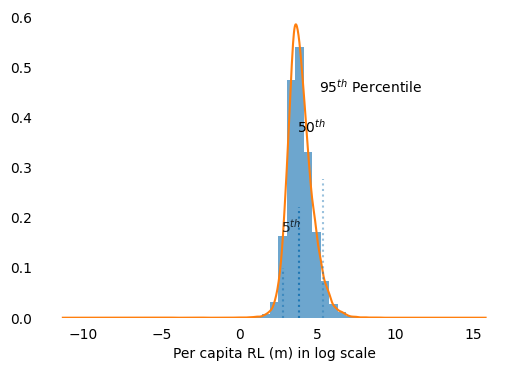

In [ ]:
log_data = np.log(roads_clean[roads_clean['city type'] == 'rural']['per_cap_mass_at_2020'])
# sns.histplot(np.log(data['per_cap_mass_at_2020']), alpha = 0.8, color= 'grey', linewidth=0.2)
# citytype_name = ['urban', 'suburban', 'periurban', 'rural']

fig, ax = plt.subplots(figsize = (6,4))

# Plot
log_data.plot(kind = "hist", density = True, alpha = 0.65, bins = 25) # change density to true, because KDE uses density
    # Plot KDE
log_data.plot(kind = "kde")

# Quantile lines
quant_5, quant_25, quant_50, quant_75, quant_95 = log_data.quantile(0.05), log_data.quantile(0.25), log_data.quantile(0.5), log_data.quantile(0.75), log_data.quantile(0.95)
quants = [[quant_5, 0.6, 0.16], [quant_50, 1, 0.36],  [quant_95, 0.45, 0.45]] # [quant_25, 0.8, 0.26], [quant_75, 0.8, 0.46], 
for i in quants:
    ax.axvline(i[0], alpha = i[1], ymax = i[2], linestyle = ":")

# X
ax.set_xlabel("Per capita RL (m) in log scale")
    # Limit x range to 0-4
x_start, x_end = 0, 15
# ax.set_xlim(x_start, x_end)

# Y
ax.set_ylabel("")

# Annotations
ax.text(quant_5-.1, 0.17, "5$^{th}$", size = 10, alpha = 0.8)
# ax.text(quant_25-.13, 0.27, "25th", size = 11, alpha = 0.8)
ax.text(quant_50-.13, 0.37, "50$^{th}$", size = 10, alpha = 1)
# ax.text(quant_75-.13, 0.47, "75th", size = 11, alpha = 0.8)
ax.text(quant_95-.25, 0.45, "95$^{th}$ Percentile", size = 10, alpha =1)

# Overall
ax.grid(False)
# Remove ticks and spines
ax.tick_params(left = False, bottom = False)
for ax, spine in ax.spines.items():
    spine.set_visible(False)
    
plt.show()

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.838
Model:                            OLS   Adj. R-squared:                  0.838
Method:                 Least Squares   F-statistic:                 3.566e+04
Date:                Sun, 15 Sep 2024   Prob (F-statistic):               0.00
Time:                        15:46:33   Log-Likelihood:                -5489.6
No. Observations:                6883   AIC:                         1.098e+04
Df Residuals:                    6881   BIC:                         1.100e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.2349      0.039    108.543      0.0

([4.158396718366816, 4.311362428270869],
 [0.8216733389294043, 0.838912856204172],
 Intercept    4.234880
 x            0.830293
 dtype: float64)

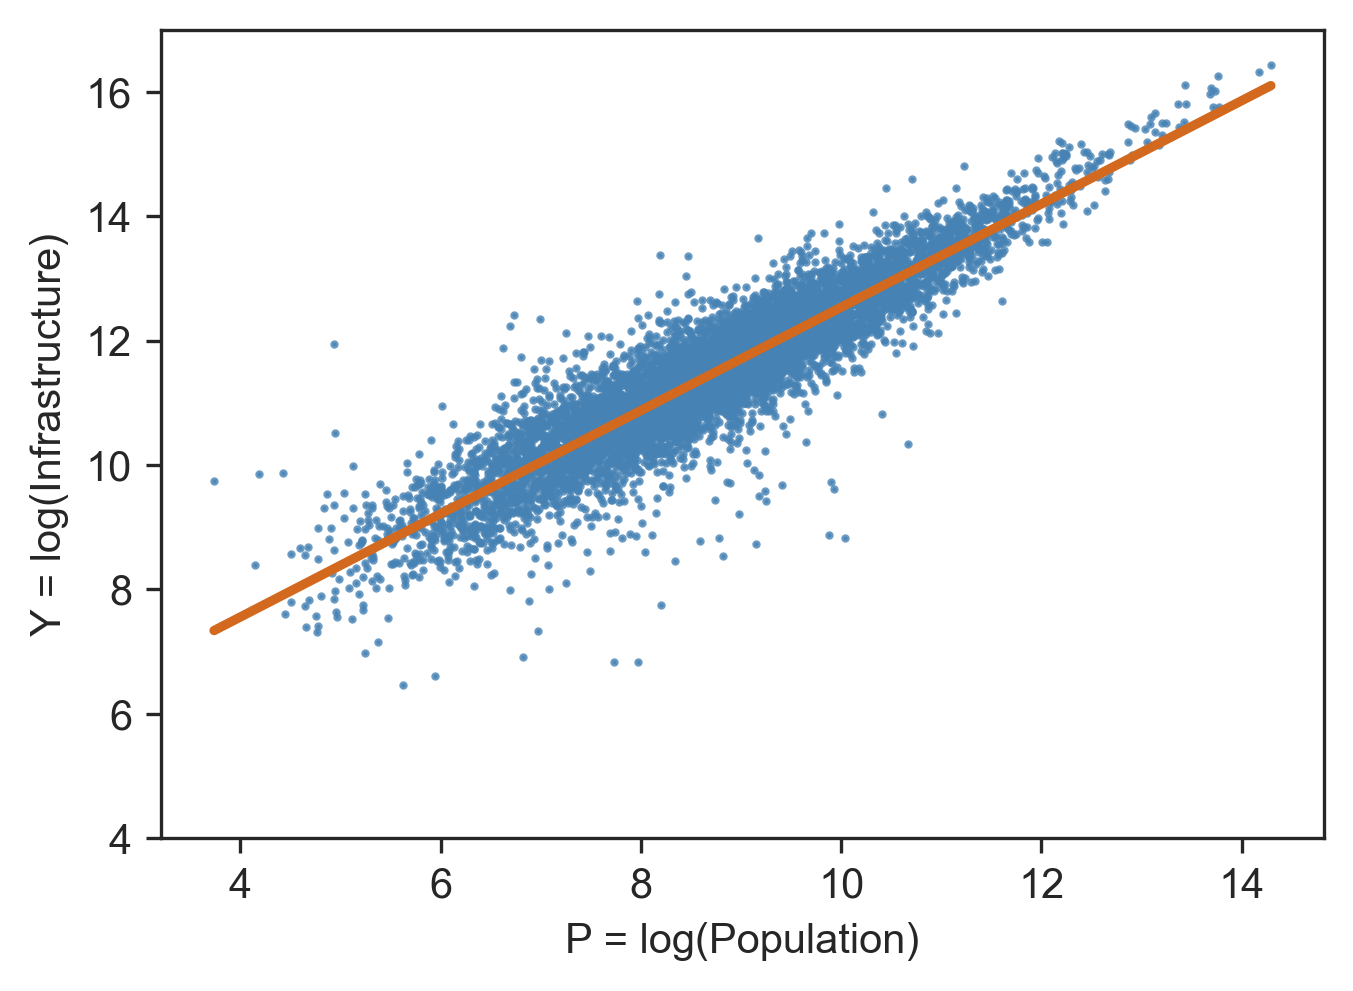

In [ ]:
def find_example_scale_parameters(df, infra_col, pop_col):
    '''
    Fit data to liner regression
    Columns are transformed to log scale before plotting
    - infra_col: total infrastructure length/ area/volume for a city
    - pop_col: population data for a city
    - returns model parameters as intercepts, beta, model_params
    '''
    df.loc[:,'log_pop_col'] = np.log(df[pop_col].astype(float))
    df.loc[:, 'log_infra_col'] = np.log(df[infra_col].astype(float))

    # fig = px.scatter(df, x='log_pop_col', y='log_infra_col', hover_data=['GEOID', 'NAMELSAD'],
    #                 width=800, height=800) 
    # fig.show()
    sns.set_style('ticks')
    fig, ax = plt.subplots(dpi=300)
    # the size of A4 paper
    fig.set_size_inches(5,3.5)
    # Check plot how the log-log plot looks?
    sns.regplot(ax=ax,x='log_pop_col', y='log_infra_col', data=df, line_kws={"color": "chocolate"}, color="steelblue",
                y_jitter=.03, ci =None, scatter_kws={"s": 1})
    ax.set(xlabel='P = log(Population)', ylabel = 'Y = log(Infrastructure)')
    ax.set_ylim(4,17)
    # fig = ax.get_figure()
    # plt.savefig(r'D:\Work\Box Sync\Applications\Senseble lab MIT\Interview docs\scalingRelation.png', transparent=True,  bbox_inches='tight')

    x = df['log_pop_col']
    y = df['log_infra_col']

    #run anova model to find confidence intervals
    # Fit the regression model
    model = sm.ols("y ~ x", data={"y": y, "x": x}).fit()

    # Display regression summary
    print(model.summary())
    print(model.params)
    print("R-squared value" , model.rsquared)
    print('====================================')
    # Calculate confidence intervals using ANOVA
    anova_result = anova_lm(model)
    conf_int = model.conf_int(alpha=0.05, cols=None)

    # Display ANOVA results and confidence intervals
    print("\nConfidence Intervals: 'log(a)' and 'b' values---")
    print(conf_int)
    intercepts = [conf_int.iloc[0][0], conf_int.iloc[0][1]]
    beta = [conf_int.iloc[1][0], conf_int.iloc[1][1]]
    model_params = model.params
    return intercepts, beta, model_params

find_example_scale_parameters(roads_clean[roads_clean['city type'] == 'suburban'],  'cl_total_length', 'CensusPop_20')

In [ ]:
roads_clean.columns

Index(['GEOID', 'NAMELSAD', 'motorway', 'trunk', 'primary', 'secondary',
       'tertiary', 'unclassified', 'residential', 'service',
       ...
       'citytype_at_2060', 'citytype_at_2070', 'citytype_at_2080',
       'citytype_at_2090', 'citytype_at_2100', 'road_density_m-sqm',
       'road_density', 'per_cap_mass_at_2020', 'city_type_order',
       'REGION_order'],
      dtype='object', length=133)

### Run loops 

### for 2030

(30498, 27)
Initial dataframe:====
(30498, 27)
Shape of the dataframe for urban:====
(312, 28)
Prune upper and lower 10 percent data before fitting to the scaling law
***DEFINITELY NEED TO VALIDATE THIS PRUNING***
Shape of dataframe used in scaling fit:===
(280, 28)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.838
Model:                            OLS   Adj. R-squared:                  0.837
Method:                 Least Squares   F-statistic:                     1438.
Date:                Sun, 15 Sep 2024   Prob (F-statistic):          7.12e-112
Time:                        15:46:34   Log-Likelihood:                -242.50
No. Observations:                 280   AIC:                             489.0
Df Residuals:                     278   BIC:                             496.3
Df Model:                           1                                         
Covariance Type:      

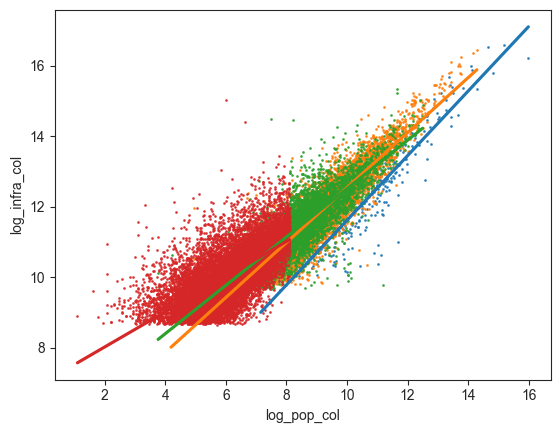

In [ ]:
import sys
# caution: path[0] is reserved for script path (or '' in REPL)
sys.path.insert(1, r'E:\Scripts\project_QI\scripts')
from functions.functions_scaling import find_scale_parameters, find_next_stock, process_stock_at_t


current_stock_col = 'cl_total_length'
current_pop_col = 'CensusPop_20'
next_pop_col = 'ssp22030'
t = 2030

roads_clean['stock_at_t0'] = roads_clean['cl_total_length']
df_for_analysis = roads_clean[['GEOID', 'State', 'NAMELSAD','city type','median_income', 'road_density_m-sqm', 'CensusPop_20', 'ssp22020', 'ssp22030', 
                                'ssp22040', 'ssp22050', 'ssp22060', 'ssp22070', 'ssp22080', 'ssp22090', 'ssp22100',
                                'citytype_at_2030', 'citytype_at_2040','citytype_at_2050', 'citytype_at_2060', 'citytype_at_2070',  'citytype_at_2080', 'citytype_at_2090', 'citytype_at_2100',
                                'cl_total_length', 'total_length', 'stock_at_t0']]


df_for_2030 = process_stock_at_t(df_for_analysis, current_stock_col, current_pop_col, next_pop_col, t)

df_for_analysis = df_for_analysis.merge(df_for_2030, on ='GEOID')
roads_clean = roads_clean.merge(df_for_2030, on ='GEOID')
print(roads_clean.shape)

df_for_analysis.rename({'surface_Res_at_2030' : 'cl_length_at_2030'}, axis=1, inplace=True)

### 2040 - 2100

(30498, 30)
Initial dataframe:====
(30498, 30)
Shape of the dataframe for urban:====
(325, 30)
Prune upper and lower 10 percent data before fitting to the scaling law
***DEFINITELY NEED TO VALIDATE THIS PRUNING***
Shape of dataframe used in scaling fit:===
(292, 30)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.835
Model:                            OLS   Adj. R-squared:                  0.834
Method:                 Least Squares   F-statistic:                     1468.
Date:                Sun, 15 Sep 2024   Prob (F-statistic):          1.68e-115
Time:                        15:47:42   Log-Likelihood:                -249.59
No. Observations:                 292   AIC:                             503.2
Df Residuals:                     290   BIC:                             510.5
Df Model:                           1                                         
Covariance Type:      

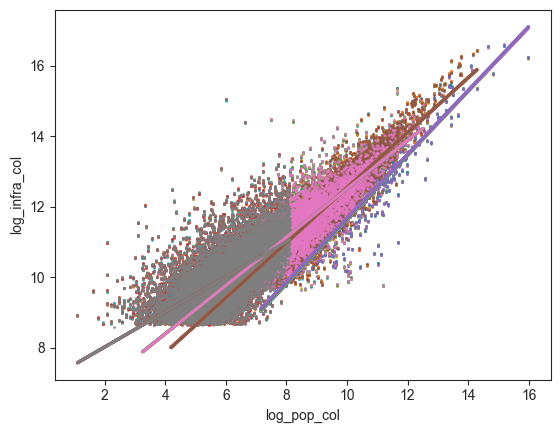

In [ ]:
current_stock_col ='cl_length_at_2030'
current_pop_col = 'ssp22030'
next_pop_col = 'ssp22040'
t = 2040

df_for_2040 = process_stock_at_t(df_for_analysis, current_stock_col, current_pop_col, next_pop_col, t)

df_for_analysis = df_for_analysis.merge(df_for_2040, on ='GEOID')
roads_clean = roads_clean.merge(df_for_2040, on ='GEOID')
print(roads_clean.shape)

df_for_analysis.rename({'surface_Res_at_2040' : 'cl_length_at_2040'}, axis=1, inplace=True)

current_stock_col ='cl_length_at_2040'
current_pop_col = 'ssp22040'
next_pop_col = 'ssp22050'
t = 2050

df_for_2050 = process_stock_at_t(df_for_analysis, current_stock_col, current_pop_col, next_pop_col, t)

df_for_analysis = df_for_analysis.merge(df_for_2050, on ='GEOID')
roads_clean = roads_clean.merge(df_for_2050, on ='GEOID')
print(roads_clean.shape)
df_for_analysis.rename({'surface_Res_at_2050' : 'cl_length_at_2050'}, axis=1, inplace=True)


current_stock_col ='cl_length_at_2050'
current_pop_col = 'ssp22050'
next_pop_col = 'ssp22060'
t = 2060

df_for_2060 = process_stock_at_t(df_for_analysis, current_stock_col, current_pop_col, next_pop_col, t)

df_for_analysis = df_for_analysis.merge(df_for_2060, on ='GEOID')
roads_clean = roads_clean.merge(df_for_2060, on ='GEOID')
print(roads_clean.shape)
df_for_analysis.rename({'surface_Res_at_2060' : 'cl_length_at_2060'}, axis=1, inplace=True)


current_stock_col ='cl_length_at_2060'
current_pop_col = 'ssp22060'
next_pop_col = 'ssp22070'
t = 2070

df_for_2070 = process_stock_at_t(df_for_analysis, current_stock_col, current_pop_col, next_pop_col, t)

df_for_analysis = df_for_analysis.merge(df_for_2070, on ='GEOID')
roads_clean = roads_clean.merge(df_for_2070, on ='GEOID')
print(roads_clean.shape)
df_for_analysis.rename({'surface_Res_at_2070' : 'cl_length_at_2070'}, axis=1, inplace=True)


current_stock_col ='cl_length_at_2070'
current_pop_col = 'ssp22070'
next_pop_col = 'ssp22080'
t = 2080

df_for_2080 = process_stock_at_t(df_for_analysis, current_stock_col, current_pop_col, next_pop_col, t)

df_for_analysis = df_for_analysis.merge(df_for_2080, on ='GEOID')
roads_clean = roads_clean.merge(df_for_2080, on ='GEOID')
print(roads_clean.shape)
df_for_analysis.rename({'surface_Res_at_2080' : 'cl_length_at_2080'}, axis=1, inplace=True)

current_stock_col ='cl_length_at_2080'
current_pop_col = 'ssp22080'
next_pop_col = 'ssp22090'
t = 2090

df_for_2090 = process_stock_at_t(df_for_analysis, current_stock_col, current_pop_col, next_pop_col, t)

df_for_analysis = df_for_analysis.merge(df_for_2090, on ='GEOID')
roads_clean = roads_clean.merge(df_for_2090, on ='GEOID')
print(roads_clean.shape)
df_for_analysis.rename({'surface_Res_at_2090' : 'cl_length_at_2090'}, axis=1, inplace=True)


current_stock_col ='cl_length_at_2090'
current_pop_col = 'ssp22090'
next_pop_col = 'ssp22100'
t = 2100

df_for_2100 = process_stock_at_t(df_for_analysis, current_stock_col, current_pop_col, next_pop_col, t)

df_for_analysis = df_for_analysis.merge(df_for_2100, on ='GEOID')
roads_clean = roads_clean.merge(df_for_2100, on ='GEOID')
print(roads_clean.shape)
df_for_analysis.rename({'surface_Res_at_2100' : 'cl_length_at_2100'}, axis=1, inplace=True)


In [ ]:
roads_clean['m-from 2020-2030'] = roads_clean['per_cap_mass_at_2030'] - roads_clean['per_cap_mass_at_2020']
roads_clean['m-from 2030-2040'] = roads_clean['per_cap_mass_at_2040'] - roads_clean['per_cap_mass_at_2030']
roads_clean['m-from 2040-2050'] = roads_clean['per_cap_mass_at_2050'] - roads_clean['per_cap_mass_at_2040']
roads_clean['m-from 2050-2060'] = roads_clean['per_cap_mass_at_2060'] - roads_clean['per_cap_mass_at_2050']
roads_clean['m-from 2060-2070'] = roads_clean['per_cap_mass_at_2070'] - roads_clean['per_cap_mass_at_2060']
roads_clean['m-from 2070-2080'] = roads_clean['per_cap_mass_at_2080'] - roads_clean['per_cap_mass_at_2070']
roads_clean['m-from 2080-2090'] = roads_clean['per_cap_mass_at_2090'] - roads_clean['per_cap_mass_at_2080']
roads_clean['m-from 2090-2100'] = roads_clean['per_cap_mass_at_2100'] - roads_clean['per_cap_mass_at_2090']

In [ ]:
# roads_clean['CityName'] = roads_clean['NAMELSAD'].str.split(' ').str[0]
df_check = roads_clean[['GEOID', 'NAMELSAD','future trend from SSP 2', 'city type', 'REGION', 'per_cap_mass_at_2020','per_cap_mass_at_2030','per_cap_mass_at_2040','per_cap_mass_at_2050',
                        'percent change from 2020-2040', 'percent change from 2040-2060', 'percent change from 2060-2080', 'percent change from 2080-2100', 'percent change from 2020-2100',
       'percent change from 2020-2060', 'percent change from 2060-2100', 'm-from 2020-2030',
       'm-from 2030-2040', 'm-from 2040-2050', 'm-from 2050-2060',
       'm-from 2060-2070', 'm-from 2070-2080', 'm-from 2080-2090',
       'm-from 2090-2100', 'per_cap_mass_at_2100']]

In [ ]:
roads_clean.to_csv(r'E:\Scripts\project_QI\outputfiles\csvs\roads_projected_x_local.csv')